TX: 'ST' | RX bytes: b'S\xd4\x8d\n\xb1\x8d\n\xaa' | prompt: None
TX: 'SRAT 1000' | RX bytes: b'S\xd2A\xd4\xa0\xb1000\x8d\n' | prompt: b'?'
TX: 'SIZE 1000' | RX bytes: b'S\xc9Z\xc5\xa0\xb1000\x8d\n' | prompt: b'?'
TX: 'STRT' | RX bytes: b'S\xd4\xd2\xd4\x8d\n\xb10\x8d\n' | prompt: b'?'
TX: 'SPTS?' | RX bytes: b'SP\xd4S' | prompt: b'?'
SPTS? -> 0/1000
TX: 'SPTS?' | RX bytes: b'\x8d\n' | prompt: b'?'
TX: 'SPTS?' | RX bytes: b'SP\xd4S' | prompt: b'?'
TX: 'SPTS?' | RX bytes: b'\x8d\n' | prompt: b'?'
TX: 'SPTS?' | RX bytes: b'SP\xd4S' | prompt: b'?'
TX: 'SPTS?' | RX bytes: b'\x8d\n' | prompt: b'?'
TX: 'SPTS?' | RX bytes: b'SP\xd4S' | prompt: b'?'
TX: 'SPTS?' | RX bytes: b'\x8d\n' | prompt: b'?'
TX: 'SPTS?' | RX bytes: b'SP\xd4S' | prompt: b'?'
TX: 'SPTS?' | RX bytes: b'\x8d\n' | prompt: b'?'
TX: 'SPTS?' | RX bytes: b'SP\xd4S' | prompt: b'?'
TX: 'SPTS?' | RX bytes: b'\x8d\n' | prompt: b'?'
TX: 'SPTS?' | RX bytes: b'SP\xd4S' | prompt: b'?'
TX: 'SPTS?' | RX bytes: b'\x8d\n' | prompt: b'?'
TX: 'S

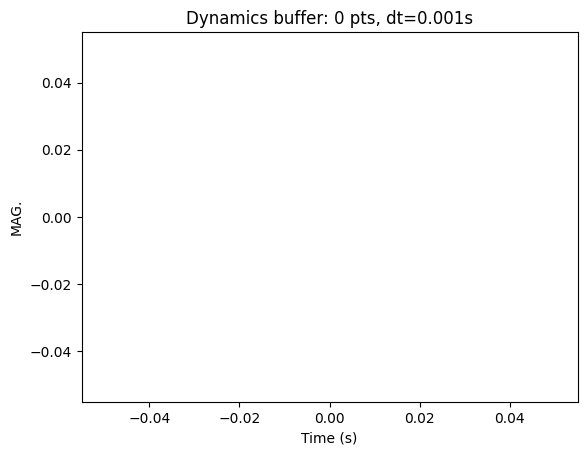

TX: 'DAC2+00000' | RX bytes: b'SP\xd4S' | prompt: b'?'
Closed.


In [13]:
import time, re
import numpy as np
import pyvisa
from pyvisa import errors as visa_errors
from pyvisa.constants import Parity, StopBits, VI_ERROR_TMO

# ---------------- User settings ----------------
PORT        = "ASRL7::INSTR"  # or "COM7" if you prefer the COM form
BAUD        = 9600
DT_S        = 0.001           # desired sample interval (s)
DURATION_S  = 1.0             # total capture time (s)
CHANNEL_CMD = "MAG."          # "MAG." or "PHA."
INTER_CHAR_DELAY = 0.06       # <-- 60 ms (increase to 0.08 if still dropping chars)
READ_DEADLINE_S  = 6.0        # overall deadline to see '*'/'?' prompt

# If your SRAT requires an INDEX (not Hz), map here (adjust for your model)
SRAT_INDEX_BY_DT = {
    1e-3: 1000, 2e-3: 500, 5e-3: 200, 1e-2: 100, 2e-2: 50, 5e-2: 20,
    1e-1: 10, 2e-1: 5, 5e-1: 2, 1.0: 1,
}
ALLOW_SRAT_HZ = True  # set False if your unit wants an index only

# ---------------- VISA helpers ----------------
def open_inst(port=PORT, baud=BAUD):
    rm = pyvisa.ResourceManager()
    inst = rm.open_resource(port)
    inst.baud_rate = baud
    inst.parity = Parity.even
    inst.data_bits = 7
    inst.stop_bits = StopBits.one
    inst.write_termination = None
    inst.read_termination  = None
    inst.timeout = 5000  # ms per read call
    return inst

def read_until_prompt(inst, endbytes=(b'*', b'?'), overall_timeout_s=READ_DEADLINE_S, max_bytes=32768):
    buf = bytearray(); prompt = None
    old_to = inst.timeout
    inst.timeout = 100  # short per-read so we can loop
    deadline = time.time() + overall_timeout_s
    try:
        while time.time() < deadline and len(buf) < max_bytes:
            try:
                b = inst.read_bytes(1)
            except visa_errors.VisaIOError as e:
                if getattr(e, "error_code", None) == VI_ERROR_TMO:
                    continue
                raise
            if not b:
                continue
            if b in endbytes:
                prompt = b
                break
            buf.extend(b)  # keep raw, including CR/LF, so we can inspect
    finally:
        inst.timeout = old_to
    return bytes(buf), prompt

def send_cmd_raw(inst, cmd: str, inter_char_delay=INTER_CHAR_DELAY):
    """Send command with per-char delay, return raw payload (no echo stripping) + prompt."""
    for ch in cmd:
        inst.write_raw(ch.encode("ascii"))
        time.sleep(inter_char_delay)
    inst.write_raw(b"\r")
    payload, prompt = read_until_prompt(inst)
    print(f"TX: {cmd!r} | RX bytes: {payload!r} | prompt: {prompt!r}")
    return payload, prompt

def parse_first_int(txt: str):
    m = re.search(r'(-?\d+)', txt)
    return int(m.group(1)) if m else None

# ---------------- Buffer helpers ----------------
def set_sample_rate(inst, dt_s: float):
    if ALLOW_SRAT_HZ:
        hz = max(1, int(round(1.0 / max(dt_s, 1e-6))))
        return send_cmd_raw(inst, f"SRAT {hz}")
    # index path
    chosen_dt = min(SRAT_INDEX_BY_DT.keys(), key=lambda d: abs(d - dt_s))
    idx = SRAT_INDEX_BY_DT[chosen_dt]
    return send_cmd_raw(inst, f"SRAT {int(idx)}")

def set_buffer_points(inst, n_points: int):
    return send_cmd_raw(inst, f"SIZE {int(n_points)}")

def buffer_start(inst):  return send_cmd_raw(inst, "STRT")
def buffer_pause(inst):  return send_cmd_raw(inst, "PAUS")

def buffer_points_collected(inst) -> int:
    raw, p = send_cmd_raw(inst, "SPTS?")
    # Try to pull an integer from the raw text
    txt = raw.decode("utf-8", errors="ignore")
    val = parse_first_int(txt)
    return val if val is not None else 0

def buffer_send(inst) -> np.ndarray:
    raw, p = send_cmd_raw(inst, "SEND")
    txt = raw.decode("utf-8", errors="ignore")
    vals = []
    for tok in re.split(r"[,\s]+", txt.strip()):
        try: vals.append(float(tok))
        except: pass
    return np.asarray(vals, dtype=float)

def select_channel_column(arr_1d: np.ndarray, channel_cmd: str) -> np.ndarray:
    if arr_1d.size == 0: return arr_1d
    if arr_1d.size % 3 == 0:
        data = arr_1d.reshape(-1, 3)
        colmap = {"MAG.": 0, "PHA.": 1, "X.": 0, "Y.": 1}
        return data[:, colmap.get(channel_cmd, 0)]
    if arr_1d.size % 2 == 0:
        return arr_1d.reshape(-1, 2)[:, 0]
    return arr_1d

# ---------------- Test sequence ----------------
n_total = max(1, int(round(DURATION_S / max(DT_S, 1e-6))))
n_total = min(n_total, 65535)

inst = None

VISA_LIBRARY = "C:/Windows/System32/visa64.dll"  # "auto" or r"C:/Windows/System32/visa64.dll", or "@py"
RS232_PORT_NAME = "ASRL7::INSTR"  # e.g. "ASRL5::INSTR"
BAUD_RATE = 9600  # e.g. 9600
rm = pyvisa.ResourceManager(VISA_LIBRARY)
inst = rm.open_resource(RS232_PORT_NAME)


try:

    # Status sanity
    send_cmd_raw(inst, "ST")

    # Configure buffer (skip 'SRAT?' probe; many firmwares don’t support it)
    set_sample_rate(inst, DT_S)
    set_buffer_points(inst, n_total)

    # Start (skip AQN if your unit rejects it)
    buffer_start(inst)

    # Poll points
    t0 = time.time()
    pts_prev = -1
    while True:
        pts = buffer_points_collected(inst)
        if pts != pts_prev:
            print(f"SPTS? -> {pts}/{n_total}")
            pts_prev = pts
        if pts >= n_total:
            break
        if time.time() - t0 > max(8.0, 4*DURATION_S):
            print("Timeout waiting for points; breaking.")
            break
        time.sleep(0.1)

    # Stop & read out
    buffer_pause(inst)
    raw = buffer_send(inst)
    print(f"SEND parsed {raw.size} numbers")

    y = select_channel_column(raw, CHANNEL_CMD)
    n_eff = min(y.size, n_total)
    y = y[:n_eff]
    t = np.arange(n_eff, dtype=float) * DT_S
    print(f"Channel {CHANNEL_CMD}: {len(y)} pts; first 10:", list(zip(t[:10], y[:10])))

    # Optional quick plot
    try:
        import matplotlib.pyplot as plt
        plt.figure()
        plt.plot(t, y, marker='o', linestyle='none', markersize=3)
        plt.xlabel("Time (s)"); plt.ylabel(CHANNEL_CMD)
        plt.title(f"Dynamics buffer: {len(y)} pts, dt={DT_S}s")
        plt.show()
    except Exception as e:
        print("Plot skipped:", e)

except Exception as e:
    print("ERROR:", type(e).__name__, e)
finally:
    if inst is not None:
        try: send_cmd_raw(inst, "DAC2+00000")
        except Exception: pass
        try: inst.close()
        except Exception: pass
        print("Closed.")


In [15]:
rm = pyvisa.ResourceManager(VISA_LIBRARY)
inst = rm.open_resource(RS232_PORT_NAME)

set_sample_rate(inst, DT_S)


TX: 'SRAT 1000' | RX bytes: b'S\xd2A\xd4\xa0\xb1000\x8d\n' | prompt: b'?'


(b'S\xd2A\xd4\xa0\xb1000\x8d\n', b'?')

In [ ]:
set_buffer_points(inst, n_total)


TX: 'SIZE 1000' | RX bytes: b'S\xc9Z\xc5\xa0\xb1000\x8d\n' | prompt: b'?'
TX: 'STRT' | RX bytes: b'S\xd4\xd2\xd4\x8d\n\xb10\x8d\n' | prompt: b'?'


(b'S\xd4\xd2\xd4\x8d\n\xb10\x8d\n', b'?')

In [28]:
# curve bugger define what mode (0 is X)
send_cmd_raw(inst, "CBD0")    
send_cmd_raw(inst, "LEN1000")    


# Defines the delay between points in ms
send_cmd_raw(inst, "STRT10")    


TX: 'CBD0' | RX bytes: b'\xc3BD0\x8d\n' | prompt: b'?'
TX: 'LEN1000' | RX bytes: b'\xcc\xc5N\xb1000\x8d\n\xaa' | prompt: None
TX: 'STRT10' | RX bytes: b'S\xd4\xd2\xd4\xb10\x8d\n\xb10\x8d\n' | prompt: b'?'


(b'S\xd4\xd2\xd4\xb10\x8d\n\xb10\x8d\n', b'?')

In [29]:
send_cmd_raw(inst, "TD")

TX: 'TD' | RX bytes: b'\xd4D\x8d\n\xaa' | prompt: None


(b'\xd4D\x8d\n\xaa', None)

In [ ]:
send_cmd_raw(inst, "DC1")

TX: 'DC1' | RX bytes: b'D\xc3\xb1\x8d\n' | prompt: b'?'


(b'D\xc3\xb1\x8d\n', b'?')

In [32]:
b = inst.read_bytes(1)
b

VisaIOError: VI_ERROR_TMO (-1073807339): Timeout expired before operation completed.